<p align="center">
<a href="https://colab.research.google.com/github/md-ryhan-uddin/ai-lab-experiments/blob/main/experiment_09.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

<a href="https://kaggle.com/kernels/welcome?src=https://github.com/md-ryhan-uddin/ai-lab-experiments/blob/main/experiment_09.ipynb">
    <img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Open In Kaggle" height="20"/>
</a>
</p>

## **Experiment 09:** Natural Language Processing using Recurrent Neural Networks (RNNs) and Long Short-Term Memory (LSTM) Networks

**Course:** ICE 4111: Artificial Intelligence Lab  
**Program:** Bachelor of Science in Information and Communication Engineering (BSc in ICE)  
**Instructor:** Md. Ryhan Uddin

**Student Name:** ______________________________  
**Student ID:** ______________________________  
**Section/Batch:** ______________________________  
**Date of Submission:** ______________________________  


### **Quick Overview**

In this lab you will preprocess movie review text into padded token sequences, then build and train a **Simple RNN** and an **LSTM** network for binary sentiment classification on the IMDB dataset. You will compare both models using learning curves, test accuracy, and confusion matrices, decode a few misclassified reviews back into readable text to see where each model struggles, and finally generate sentiment predictions on brand-new review sentences.

### **Learning Objectives**

After completing this experiment, students will be able to:

- Preprocess raw text into tokenized, padded integer sequences suitable for a neural network.
- Build and train a Simple RNN and an LSTM for sequence classification.
- Compare the two architectures using learning curves, test accuracy, and confusion matrices.
- Correctly encode new, unseen text using the same vocabulary the model was trained on.
- Interpret model errors by decoding misclassified reviews back into readable text.


## **Theory**

### Introduction

Recurrent neural networks are designed for sequential data such as text, speech, and time series. Unlike feedforward networks, they maintain a hidden state that carries information from one time step to the next, which makes them suitable for language tasks where the meaning of a word depends on earlier words in the sequence. Long Short-Term Memory (LSTM) networks are a special type of RNN designed to reduce the vanishing-gradient problem and remember useful context over longer spans of text.

### Mathematical Background

At time step $t$, a Simple RNN updates its hidden state using

$$h_t = \phi\big(W_x x_t + W_h h_{t-1} + b\big)$$

where $x_t$ is the input at step $t$ and $\phi$ is typically $\tanh$. The output can be computed from the final hidden state using another affine transformation.

LSTM networks replace this simple update with input, forget, and output gates that control what information is stored, forgotten, or emitted:

$$f_t = \sigma(W_f [h_{t-1}, x_t] + b_f), \quad i_t = \sigma(W_i [h_{t-1}, x_t] + b_i), \quad o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$$

$$c_t = f_t \odot c_{t-1} + i_t \odot \tanh(W_c [h_{t-1}, x_t] + b_c), \qquad h_t = o_t \odot \tanh(c_t)$$

The gates let the network learn what to keep in its memory cell $c_t$ over long sequences, which helps it capture longer-range dependencies than a Simple RNN.

### Important Concepts

A typical NLP workflow is: tokenize the text, convert tokens to integers using a fixed vocabulary, pad the sequences to a common length, split the data, train an embedding-based sequence model, and evaluate it on a held-out set. The **embedding layer** converts each integer token into a dense, trainable vector, giving the model a richer representation than a raw one-hot or index encoding. The RNN processes tokens one at a time and updates its hidden state; the LSTM uses gating to selectively preserve or discard context as it moves through the sequence.

A subtle but important point: **any new text must be encoded using the exact same word-to-index mapping the model was trained on.** If new text is tokenized with a different vocabulary (for example, one built only from a couple of new sentences), the resulting integer IDs will not correspond to the same words the embedding layer learned, and predictions will be meaningless. This is handled carefully later in the notebook.

### Advantages and Applications

**Advantages**

- Simple RNNs are conceptually straightforward and cheap to train.
- LSTMs are far more effective for realistic language tasks because their gating mechanism helps them remember relevant context over longer spans.

**Disadvantages**

- Simple RNNs often struggle with long sequences due to vanishing gradients.
- Both RNNs and LSTMs process tokens sequentially, so they are slower to train and parallelize less well than transformer-based language models.

**Applications**

These models are widely used in sentiment analysis, sequence tagging (e.g. named entity recognition), and language modeling.

```mermaid
flowchart LR
    T[Raw Text] --> K[Tokenizer / Word Index]
    K --> P[Padding to Fixed Length]
    P --> E[Embedding Layer]
    E --> R[Simple RNN or LSTM]
    R --> C[Dense + Sigmoid]
    C --> S[Sentiment: Positive / Negative]
```


## **Required Software and Libraries**

Install or prepare the following before starting the lab:

- Python 3.12 or later
- Jupyter Notebook, JupyterLab, VS Code, or Google Colab
- NumPy
- Pandas
- Matplotlib
- TensorFlow 2.x / Keras
- Scikit-learn
- An active internet connection, required the first time `tf.keras.datasets.imdb` downloads the dataset and its word index (Colab has this by default)

### Starter Check

Run the first code cell (library imports and setup). If it prints `Setup complete. You can start the experiment.`, your environment is ready.

## **Dataset Description**

This experiment uses the **IMDB movie review sentiment dataset** bundled with TensorFlow/Keras, a standard benchmark for sequence models.

- **Features:** movie reviews, already tokenized and represented as sequences of word-frequency-ranked integer indices.
- **Target labels:** positive (1) or negative (0) review sentiment.
- **Source:** `tf.keras.datasets.imdb`.
- **Reason for selection:** a compact, widely used benchmark that is well suited to demonstrating sequence modeling and sentiment analysis without needing to build a vocabulary from scratch.

## **Experimental Procedure**

Follow the steps below in order:

1. Load the IMDB dataset, keeping a manageable vocabulary size, and pad all sequences to the same length.
2. Inspect a decoded sample review alongside its label to understand the raw data.
3. Split the training data into training and validation sets.
4. Build a Simple RNN model and train it with early stopping.
5. Build an LSTM model and train it under the same conditions.
6. Compare test accuracy, learning curves, and confusion matrices for both models.
7. Decode a few misclassified reviews to inspect where the stronger model struggles.
8. Correctly encode brand-new review sentences and generate sentiment predictions from both models.

### Student Checkpoint

Before moving to the discussion section, make sure you can answer:

- Why is `maxlen` used when padding sequences, and what happens to reviews longer or shorter than this length?
- At what epoch did early stopping halt training for each model, and which model converged faster?
- Why must new review text be encoded using the same `word_index` mapping from `tf.keras.datasets.imdb`, rather than a freshly fitted tokenizer?


## **Source Code**

Run the following cells one by one. Read the output after each cell and add comments in your own words where instructed by your teacher.

**Tip:** Do not only run the notebook. Try replacing `SimpleRNN` with a `GRU` layer, or changing `max_length`, and observe what changes.

**Note:** The dataset-loading cell downloads the IMDB dataset and its word index the first time it runs, so it requires an active internet connection (Colab provides this automatically).

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # suppress verbose TensorFlow startup logs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
tf.get_logger().setLevel("ERROR")

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

tf.keras.utils.set_random_seed(42)
np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

print("Setup complete. You can start the experiment.")

Setup complete. You can start the experiment.


In [2]:
# Load the IMDB Dataset and Pad Sequences

vocab_size = 10000
max_length = 200

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.imdb.load_data(num_words=vocab_size)
X_train = tf.keras.preprocessing.sequence.pad_sequences(X_train, maxlen=max_length)
X_test = tf.keras.preprocessing.sequence.pad_sequences(X_test, maxlen=max_length)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Class balance (train):", np.bincount(y_train))

Train shape: (25000, 200)
Test shape : (25000, 200)
Class balance (train): [12500 12500]


In [3]:
# Inspect a Decoded Sample Review

word_index = tf.keras.datasets.imdb.get_word_index()
reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index[0] = "<pad>"
reverse_word_index[1] = "<start>"
reverse_word_index[2] = "<unk>"
reverse_word_index[3] = "<unused>"

def decode_review(encoded_review):
    return " ".join(reverse_word_index.get(i, "<unk>") for i in encoded_review if i != 0)

sample_idx = 0
print("Label   :", "positive" if y_train[sample_idx] == 1 else "negative")
print("Review  :", decode_review(X_train[sample_idx]))

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 25s 15us/step
Label   : positive
Review  : and you could just imagine being there robert <unk> is an amazing actor and now the same being director <unk> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <unk> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <unk> to the two little boy's that played the <unk> of norman and paul they were just brilliant children are often left out of the <unk> list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you think the whole s

In [4]:
# Train / Validation Split

X_train, X_val = X_train[:20000], X_train[20000:25000]
y_train, y_val = y_train[:20000], y_train[20000:25000]

print("Train shape     :", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape      :", X_test.shape)

Train shape     : (20000, 200)
Validation shape: (5000, 200)
Test shape      : (25000, 200)


In [5]:
# Build the Simple RNN Model

rnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(max_length,)),
    tf.keras.layers.Embedding(vocab_size, 64),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 643,137 (2.45 MB)

 Trainable params: 643,137 (2.45 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train the RNN with Early Stopping

rnn_history = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=6,
    batch_size=128,
    verbose=1,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)],
)

print(f"RNN training completed after {len(rnn_history.history['loss'])} epochs.")

Epoch 1/6


157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 145ms/step - accuracy: 0.6091 - loss: 0.6481 - val_accuracy: 0.7308 - val_loss: 0.5453
Epoch 2/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 120ms/step - accuracy: 0.7897 - loss: 0.4720 - val_accuracy: 0.8060 - val_loss: 0.4439
Epoch 3/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 109ms/step - accuracy: 0.8762 - loss: 0.3121 - val_accuracy: 0.8190 - val_loss: 0.4139
Epoch 4/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 90ms/step - accuracy: 0.9303 - loss: 0.2084 - val_accuracy: 0.8202 - val_loss: 0.4257
Epoch 5/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 92ms/step - accuracy: 0.9610 - loss: 0.1306 - val_accuracy: 0.8312 - val_loss: 0.4237
RNN training completed after 5 epochs.


In [8]:
# Evaluate the RNN on the Test Set

rnn_test_prob = rnn_model.predict(X_test, verbose=0).ravel()
rnn_test_pred = (rnn_test_prob >= 0.5).astype(int)

rnn_accuracy = accuracy_score(y_test, rnn_test_pred)
print(f"RNN Test Accuracy : {rnn_accuracy:.4f}")
print(classification_report(y_test, rnn_test_pred, target_names=["negative", "positive"]))

RNN Test Accuracy : 0.8251
              precision    recall  f1-score   support

    negative       0.83      0.81      0.82     12500
    positive       0.82      0.84      0.83     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000



In [9]:
# Build the LSTM Model

lstm_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(max_length,)),
    tf.keras.layers.Embedding(vocab_size, 64),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,449 (2.49 MB)

 Trainable params: 652,449 (2.49 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train the LSTM with Early Stopping

lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=6,
    batch_size=128,
    verbose=1,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)],
)

print(f"LSTM training completed after {len(lstm_history.history['loss'])} epochs.")

Epoch 1/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 181ms/step - accuracy: 0.6668 - loss: 0.5877 - val_accuracy: 0.8556 - val_loss: 0.3438
Epoch 2/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 46s 212ms/step - accuracy: 0.8868 - loss: 0.2839 - val_accuracy: 0.8700 - val_loss: 0.3103
Epoch 3/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 35s 171ms/step - accuracy: 0.9175 - loss: 0.2165 - val_accuracy: 0.8708 - val_loss: 0.3321
Epoch 4/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 189ms/step - accuracy: 0.9212 - loss: 0.2032 - val_accuracy: 0.8580 - val_loss: 0.4243
LSTM training completed after 4 epochs.


In [11]:
# Evaluate the LSTM on the Test Set

lstm_test_prob = lstm_model.predict(X_test, verbose=0).ravel()
lstm_test_pred = (lstm_test_prob >= 0.5).astype(int)

lstm_accuracy = accuracy_score(y_test, lstm_test_pred)
print(f"LSTM Test Accuracy : {lstm_accuracy:.4f}")
print(classification_report(y_test, lstm_test_pred, target_names=["negative", "positive"]))

LSTM Test Accuracy : 0.8660
              precision    recall  f1-score   support

    negative       0.89      0.83      0.86     12500
    positive       0.84      0.90      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



In [12]:
# Compare RNN vs LSTM

comparison_df = pd.DataFrame([
    ["Simple RNN", rnn_accuracy, len(rnn_history.history["loss"])],
    ["LSTM", lstm_accuracy, len(lstm_history.history["loss"])],
], columns=["Model", "Test Accuracy", "Epochs Trained"]).round(4)

comparison_df

,Model,Test Accuracy,Epochs Trained
0,Simple RNN,0.8251,5
1,LSTM,0.8660,4


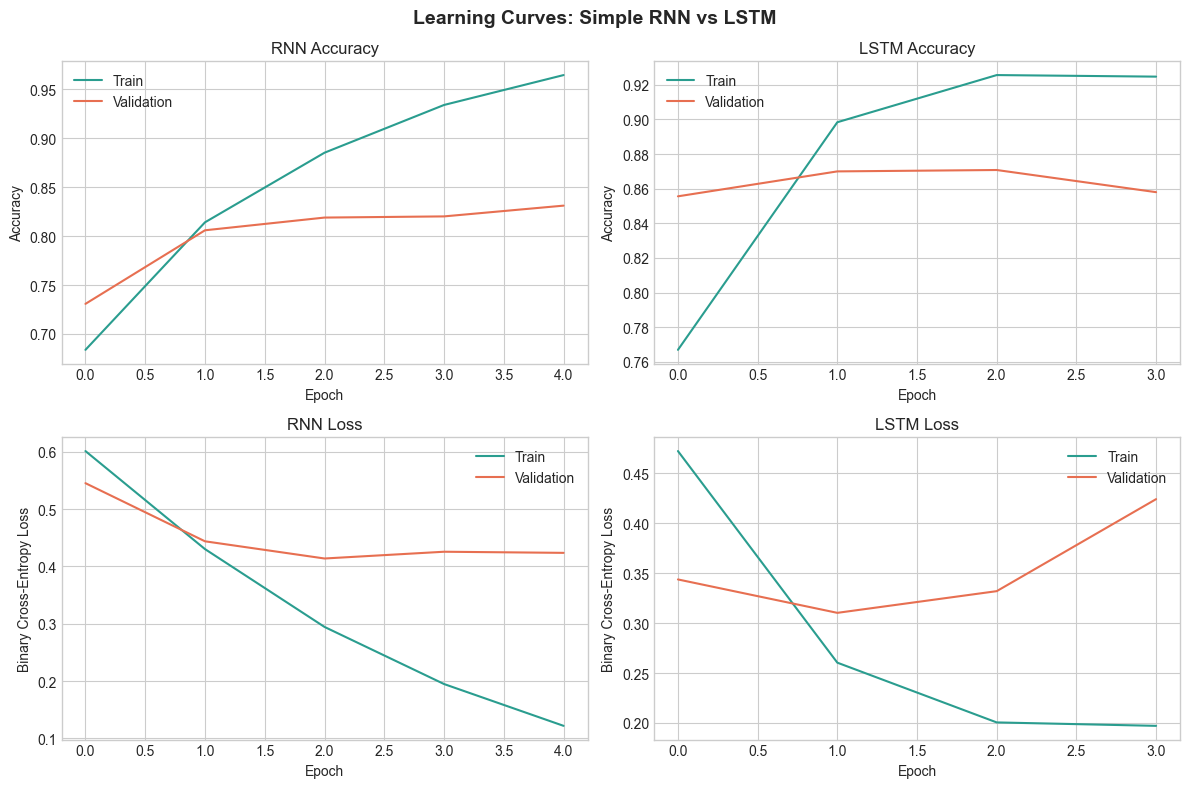

In [13]:
# Training vs Validation Accuracy and Loss: RNN vs LSTM

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(rnn_history.history["accuracy"], label="Train", color="#2a9d8f")
axes[0, 0].plot(rnn_history.history["val_accuracy"], label="Validation", color="#e76f51")
axes[0, 0].set_title("RNN Accuracy")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].legend()

axes[0, 1].plot(lstm_history.history["accuracy"], label="Train", color="#2a9d8f")
axes[0, 1].plot(lstm_history.history["val_accuracy"], label="Validation", color="#e76f51")
axes[0, 1].set_title("LSTM Accuracy")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].legend()

axes[1, 0].plot(rnn_history.history["loss"], label="Train", color="#2a9d8f")
axes[1, 0].plot(rnn_history.history["val_loss"], label="Validation", color="#e76f51")
axes[1, 0].set_title("RNN Loss")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Binary Cross-Entropy Loss")
axes[1, 0].legend()

axes[1, 1].plot(lstm_history.history["loss"], label="Train", color="#2a9d8f")
axes[1, 1].plot(lstm_history.history["val_loss"], label="Validation", color="#e76f51")
axes[1, 1].set_title("LSTM Loss")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Binary Cross-Entropy Loss")
axes[1, 1].legend()

plt.suptitle("Learning Curves: Simple RNN vs LSTM", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

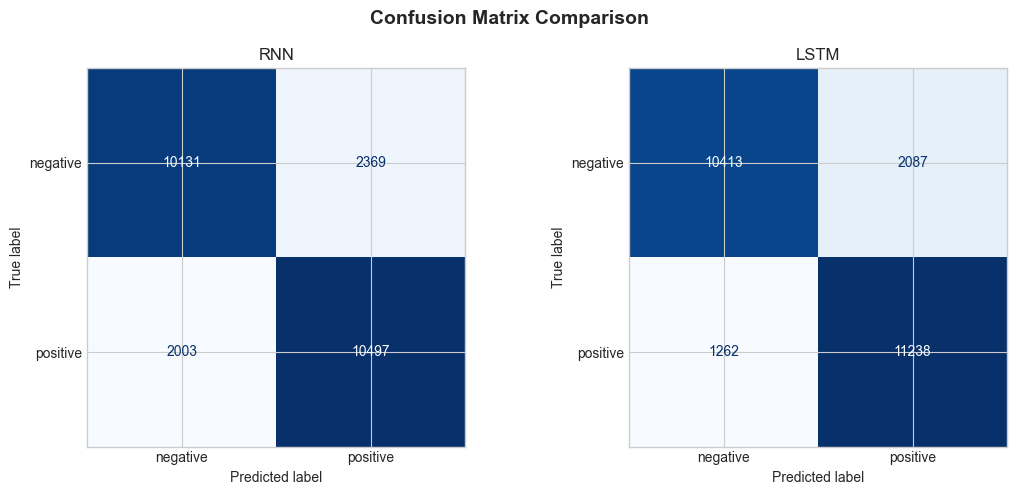

In [14]:
# Confusion Matrices: RNN vs LSTM

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, name, pred in [(axes[0], "RNN", rnn_test_pred), (axes[1], "LSTM", lstm_test_pred)]:
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negative", "positive"])
    disp.plot(cmap="Blues", ax=ax, colorbar=False, values_format="d")
    ax.set_title(name)

plt.suptitle("Confusion Matrix Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [15]:
# Inspect Misclassified Reviews from the Stronger Model

if lstm_accuracy >= rnn_accuracy:
    best_name, best_pred = "LSTM", lstm_test_pred
else:
    best_name, best_pred = "RNN", rnn_test_pred

misclassified = np.where(best_pred != y_test)[0]
print(f"Best model: {best_name}  |  Misclassified: {len(misclassified)} / {len(y_test)}")

for idx in misclassified[:3]:
    true_label = "positive" if y_test[idx] == 1 else "negative"
    pred_label = "positive" if best_pred[idx] == 1 else "negative"
    print(f"\nTrue: {true_label}  |  Predicted: {pred_label}")
    print(decode_review(X_test[idx])[:400], "...")

Best model: LSTM  |  Misclassified: 3349 / 25000

True: negative  |  Predicted: positive
<start> hollywood had a long love affair with bogus <unk> nights tales but few of these products have stood the test of time the most memorable were the jon hall maria <unk> films which have long since become camp this one is filled with dubbed songs <unk> <unk> and slapstick it's a truly crop of corn and pretty near <unk> today it was nominated for its imaginative special effects which are almost ...

True: negative  |  Predicted: positive
<start> ed <unk> mitchell is a teenager who lives for his job at good <unk> a small but friendly neighborhood <unk> stand while his buddy <unk> thompson also works there but lack <unk> single minded devotion to his job he's there because he accidentally destroyed the car of his teacher mr <unk> <unk> and has to raise money to pay the <unk> when <unk> <unk> a <unk> fast foot chain opens across the  ...

True: negative  |  Predicted: positive
<start> if you have n

In [16]:
# Predict Sentiment on Brand-New Review Sentences
#
# New text must be encoded with the SAME word_index the model was trained on,
# not a freshly fitted tokenizer, or the integer IDs won't match what the
# embedding layer learned.

def encode_review(text, word_index, vocab_size, max_length):
    tokens = text.lower().replace(".", "").replace(",", "").split()
    encoded = [1]  # <start> token, matching the IMDB dataset's convention
    for word in tokens:
        index = word_index.get(word, 0) + 3  # +3 offset used by tf.keras.datasets.imdb
        encoded.append(index if index < vocab_size else 2)  # 2 = <unk>
    return tf.keras.preprocessing.sequence.pad_sequences([encoded], maxlen=max_length)

sample_reviews = [
    "The movie was inspiring and beautifully acted.",
    "The plot was confusing and the dialogue felt weak.",
]

print(f"{'Review':55s} {'RNN':>18s} {'LSTM':>18s}")
for review in sample_reviews:
    encoded = encode_review(review, word_index, vocab_size, max_length)

    rnn_prob = rnn_model.predict(encoded, verbose=0).ravel()[0]
    lstm_prob = lstm_model.predict(encoded, verbose=0).ravel()[0]

    rnn_label = f"{'positive' if rnn_prob >= 0.5 else 'negative'} ({rnn_prob:.3f})"
    lstm_label = f"{'positive' if lstm_prob >= 0.5 else 'negative'} ({lstm_prob:.3f})"

    print(f"{review:55s} {rnn_label:>18s} {lstm_label:>18s}")

Review                                                                 RNN               LSTM
The movie was inspiring and beautifully acted.            positive (0.731)   positive (0.640)
The plot was confusing and the dialogue felt weak.        negative (0.115)   negative (0.145)


## **Expected Output**

After running all cells, the notebook should display:

- Train/test shapes and the class balance.
- A decoded sample review alongside its true label.
- Model summaries for both the RNN and the LSTM, and the epoch each stopped at.
- Test accuracy and a full classification report for both models.
- A comparison table of test accuracy and epochs trained.
- Accuracy and loss learning curves for both models.
- Confusion matrices for both models.
- A few decoded misclassified reviews from the stronger model.
- Sentiment predictions from both models on two brand-new review sentences.

You should include the important outputs in your lab report and briefly explain what each output means.

## **Discussion**

Simple RNNs are a good introduction to sequence processing, but they often struggle with long-range dependencies because gradients can vanish as they are propagated back through many time steps. LSTMs address this problem with input, forget, and output gates that let the network learn what to remember and what to discard, which usually helps them outperform simple RNNs on sentiment tasks with longer sequences like IMDB reviews. Decoding a few misclassified reviews is a useful diagnostic: sentiment that depends on sarcasm, negation spanning several words, or mixed opinions within a single review is often where both models still struggle. In practice, both RNNs and LSTMs are slower to train than transformer-based language models because they process tokens sequentially rather than in parallel.

## **Viva Questions**

1. **Q:** Why do we need padding for sequences?  
   **A:** To make all sequences the same length so they can be processed together in batches.

2. **Q:** What is an embedding layer?  
   **A:** A trainable layer that converts token indices into dense vector representations.

3. **Q:** What problem do LSTMs solve compared to Simple RNNs?  
   **A:** The vanishing-gradient problem, which makes it hard for Simple RNNs to learn long-range dependencies.

4. **Q:** What is the hidden state in an RNN?  
   **A:** A vector that carries information from previous time steps forward through the sequence.

5. **Q:** Why is the IMDB dataset popular for this kind of experiment?  
   **A:** It is a standard, readily available benchmark for binary sentiment analysis.

6. **Q:** What does binary cross-entropy measure?  
   **A:** The difference between the predicted probability and the true binary label.

7. **Q:** Why can RNNs and LSTMs be slow to train?  
   **A:** Because they process tokens sequentially, one time step at a time, which limits parallelization.

8. **Q:** What do the gates in an LSTM cell control?  
   **A:** The input gate controls what new information is stored, the forget gate controls what is discarded, and the output gate controls what is emitted from the cell state.

9. **Q:** Why must new review text be encoded using the original `word_index`, not a newly fitted tokenizer?  
   **A:** Because the embedding layer was trained on specific integer IDs from that vocabulary; a new tokenizer would assign different IDs to the same words, making predictions meaningless.

10. **Q:** Why is sentiment analysis a useful application of sequence models?  
    **A:** It automatically infers the polarity or opinion expressed in text, which is useful for reviews, feedback, and social media analysis at scale.

## **Exercises**

Complete the following tasks after running the notebook:

1. Change `max_length` (e.g. to 100 or 300) and compare test accuracy and training time for both models.
2. Replace `SimpleRNN` with a `GRU` layer and evaluate the change in accuracy and convergence speed.
3. Increase the embedding dimension (e.g. from 64 to 128) and observe the effect on training time and accuracy.
4. Stack a second recurrent layer (e.g. `LSTM(32, return_sequences=True)` followed by another `LSTM(32)`) and compare the results.
5. Write three of your own review sentences, including at least one with negation ("not good") or mixed sentiment, and see how each model handles them.

## **Lab Report Submission Checklist**

Before submitting, confirm that your report includes:

- Completed cover information.
- Objective and theory summary in your own words.
- All important code outputs, including both classification reports and the comparison table.
- The learning curves, confusion matrices, and at least one decoded misclassified review.
- The sentiment predictions on the new review sentences from both models.
- Short discussion of which model performed best and why.
- Answers to assigned viva questions.
- Completed exercises.

**Reminder:** A good lab report should not only show screenshots. It should explain what the outputs mean.
